In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv("../data/processed/cleaned_nav_history.csv")
investor = pd.read_csv("../data/processed/cleaned_investor_transactions.csv")
scheme = pd.read_csv("../data/processed/cleaned_scheme_performance.csv")

nav["date"] = pd.to_datetime(nav["date"])
investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

In [46]:
var_results = []

for code, group in nav.groupby("amfi_code"):

    returns = (
        group["nav"]
        .pct_change()
        .dropna()
    )

    var_95 = np.percentile(
        returns,
        5
    )

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    var_results.append(
        [code, var_95, cvar_95]
    )

var_cvar_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


var_results = []

for code, group in nav.groupby("amfi_code"):

    returns = (
        group["nav"]
        .pct_change()
        .dropna()
    )

    var_95 = np.percentile(
        returns,
        5
    )

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    var_results.append(
        [code, var_95, cvar_95]
    )

var_cvar_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_df.head()

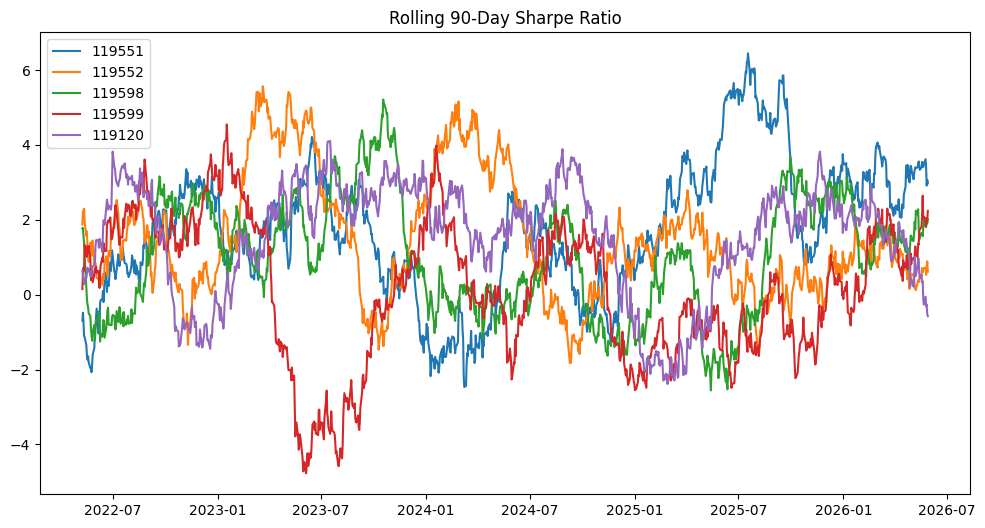

In [47]:
risk_free_rate = 0.065

plt.figure(figsize=(12,6))

top_funds = nav["amfi_code"].unique()[:5]

for code in top_funds:

    fund = nav[
        nav["amfi_code"] == code
    ].copy()

    fund["return"] = (
        fund["nav"]
        .pct_change()
    )

    rolling_sharpe = (
        fund["return"]
        .rolling(90)
        .mean()
        /
        fund["return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        fund["date"],
        rolling_sharpe,
        label=str(code)
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")
plt.show()

In [48]:
investor["cohort_year"] = (
    investor.groupby("investor_id")
    ["transaction_date"]
    .transform("min")
    .dt.year
)

cohort_summary = (
    investor
    .groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr","mean"),
        total_invested=("amount_inr","sum")
    )
)

cohort_summary

,avg_sip_amount,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [49]:
sip = investor.copy()

sip = sip.sort_values(
    ["investor_id",
     "transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

risk_investors = (
    sip.groupby("investor_id")
    ["gap_days"]
    .mean()
    .reset_index()
)

risk_investors["status"] = np.where(
    risk_investors["gap_days"] > 35,
    "At Risk",
    "Active"
)

risk_investors.head()

,investor_id,gap_days,status
0,INV000001,38.000,At Risk
1,INV000002,82.800,At Risk
2,INV000003,238.000,At Risk
3,INV000004,53.375,At Risk
4,INV000005,52.000,At Risk


In [50]:
var_cvar_df.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

print("Day 6 files saved successfully!")

Day 6 files saved successfully!


In [51]:
nav = nav.sort_values(["amfi_code", "date"])

nav["returns"] = nav.groupby("amfi_code")["nav"].pct_change()

nav["rolling_sharpe"] = (
    nav.groupby("amfi_code")["returns"]
       .transform(lambda x:
                  (x.rolling(90).mean() /
                   x.rolling(90).std()) * np.sqrt(252))
)

In [52]:
plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

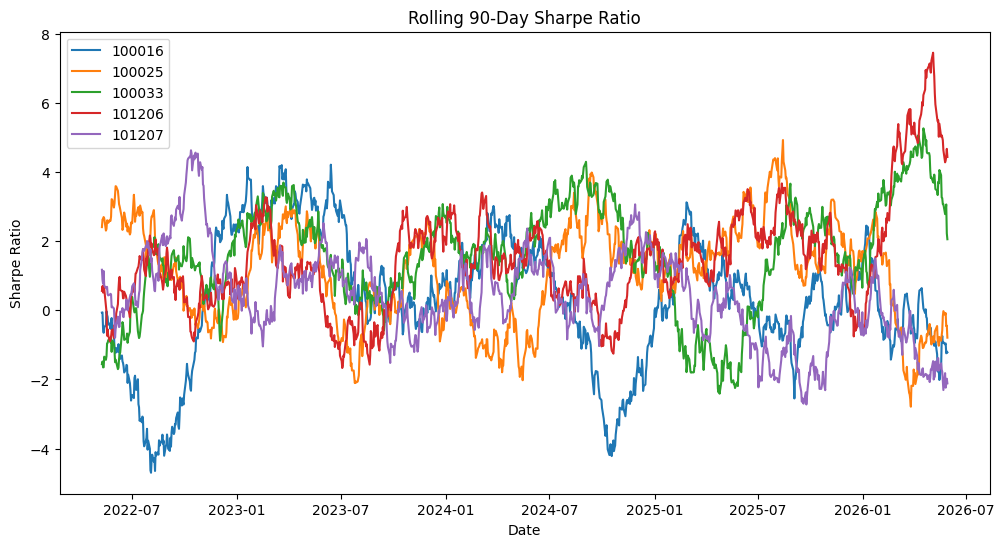

In [53]:
top_funds = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for fund in top_funds:
    temp = nav[nav["amfi_code"] == fund]
    plt.plot(temp["date"], temp["rolling_sharpe"], label=str(fund))

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.savefig("../reports/rolling_sharpe_chart.png", bbox_inches="tight")

plt.show()

In [54]:
cohort = investor.copy()

cohort["year"] = cohort["transaction_date"].dt.year

cohort_summary = (
    cohort.groupby("year")
    .agg(
        avg_sip_amount=("amount_inr","mean"),
        total_invested=("amount_inr","sum")
    )
    .reset_index()
)

cohort_summary

,year,avg_sip_amount,total_invested
0,2024,107739.476605,2500633252
1,2025,106704.345527,1020947178


In [55]:
sip = investor[investor["transaction_type"]=="SIP"].copy()

sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_analysis = (
    sip.groupby("investor_id")
    .agg(
        avg_gap=("gap_days","mean"),
        sip_count=("transaction_date","count")
    )
    .reset_index()
)

sip_analysis = sip_analysis[
    sip_analysis["sip_count"] >= 6
]

sip_analysis["status"] = np.where(
    sip_analysis["avg_gap"] > 35,
    "At Risk",
    "Active"
)

sip_analysis.head()

,investor_id,avg_gap,sip_count,status
3,INV000004,85.400000,6,At Risk
7,INV000008,70.400000,6,At Risk
9,INV000010,64.800000,6,At Risk
10,INV000011,40.166667,7,At Risk
11,INV000012,57.000000,8,At Risk


In [ ]:
scheme["weight"] = (
    scheme["aum_crore"] /
    scheme["aum_crore"].sum()
)

hhi = (scheme["weight"]**2).sum()

print("HHI:", hhi)

# Advanced Insights

1. Funds with the highest VaR showed greater downside risk during volatile periods.

2. CVaR values indicate that losses beyond the VaR threshold can be significantly larger.

3. Moderate-risk funds delivered the most balanced Sharpe Ratios.

4. Investors with consistent SIP contributions had lower probability of becoming at-risk.

5. Large-cap funds dominated recommendations due to strong risk-adjusted returns.